In [1]:
import pandas as pd

df1 = pd.read_csv('/kaggle/input/topfacialregions/top_facial_regions_dataset.csv')
df2 = pd.read_csv('/kaggle/input/mfcc-top-features/MFCC_important_feature.csv')

In [2]:
print("Face CSV file:")
df1.head()

Face CSV file:


,lipsUpperOuter_61,lipsUpperOuter_185,lipsUpperOuter_40,lipsUpperOuter_39,lipsUpperOuter_37,lipsUpperOuter_0,lipsUpperOuter_267,lipsUpperOuter_269,lipsUpperOuter_270,lipsUpperOuter_409,...,leftCheek_436,leftCheek_416,leftCheek_432,leftCheek_434,leftCheek_422,leftCheek_430,leftCheek_364,leftCheek_394,leftCheek_371,is_stroke_face
0,-0.796998,-0.783761,-0.854249,-1.005285,-1.792751,-29.106225,2.036443,1.081125,0.908469,0.832174,...,0.436471,0.406742,0.624146,0.561062,0.876275,0.871828,0.710128,0.976405,-0.134716,1
1,-0.642420,-0.637615,-0.723670,-0.889811,-1.550794,-6.475804,3.615617,1.600363,1.280204,1.130504,...,0.617774,0.618373,0.926578,0.853487,1.379093,1.413742,1.122774,1.634850,-0.205107,1
2,-0.788563,-0.800038,-0.889967,-1.072733,-2.086448,9.135111,1.369078,0.754315,0.631121,0.568725,...,0.186183,0.158452,0.354429,0.293867,0.554730,0.543838,0.411882,0.618886,-0.595886,1
3,-2.699764,-2.638462,-2.861563,-3.422442,-7.638168,12.177414,3.140405,1.905193,1.654674,1.538375,...,0.778128,0.764361,1.228064,1.113862,1.775543,1.800757,1.456326,2.028305,-0.741644,1
4,-0.570210,-0.582949,-0.669734,-0.824996,-1.521187,-13.638438,2.015914,0.966277,0.770261,0.666191,...,0.255883,0.230079,0.448418,0.385427,0.694891,0.692805,0.522984,0.789427,-0.455395,1


In [3]:
print("\nMFCC CSV file:")
df2.head()


MFCC CSV file:


,0,36,82,49,12,24,14,45,35,117,...,17,80,75,122,121,73,127,125,110,class
0,-398.97055,0.643070,-0.082618,-0.626069,-2.605149,0.169234,5.158936,-1.069310,0.996082,-0.107622,...,-0.403323,0.584761,0.796598,-0.262222,-0.650705,0.301149,-0.188446,-0.257223,1.308860,1
1,-232.39255,-2.081796,0.518272,-0.584924,-1.054728,-3.284457,8.884685,3.845485,0.056364,0.169014,...,-0.775419,-0.896011,-2.070404,-0.022294,0.166091,-0.027320,-0.390595,0.264451,0.036457,1
2,-466.48450,-0.686953,0.154127,1.862350,5.793727,0.856521,3.335157,1.209667,2.896147,0.387918,...,1.396552,0.450076,0.233947,0.154122,0.237405,0.607886,0.285212,-0.073312,0.899342,1
3,-466.73505,0.354227,0.893241,2.739482,6.860754,1.779491,-1.749699,2.230495,0.916992,0.521781,...,2.674563,0.371232,0.142578,0.071348,-0.274066,0.610250,-0.105873,0.000649,0.777924,1
4,-426.44970,-0.146068,0.319562,0.793730,3.329647,-1.323783,2.997393,0.707389,1.125068,-0.113349,...,-1.877208,0.686355,1.219750,0.138273,0.070115,2.272153,0.120445,-0.295089,1.216608,1


In [4]:
df2.head()

,0,36,82,49,12,24,14,45,35,117,...,17,80,75,122,121,73,127,125,110,class
0,-398.97055,0.643070,-0.082618,-0.626069,-2.605149,0.169234,5.158936,-1.069310,0.996082,-0.107622,...,-0.403323,0.584761,0.796598,-0.262222,-0.650705,0.301149,-0.188446,-0.257223,1.308860,1
1,-232.39255,-2.081796,0.518272,-0.584924,-1.054728,-3.284457,8.884685,3.845485,0.056364,0.169014,...,-0.775419,-0.896011,-2.070404,-0.022294,0.166091,-0.027320,-0.390595,0.264451,0.036457,1
2,-466.48450,-0.686953,0.154127,1.862350,5.793727,0.856521,3.335157,1.209667,2.896147,0.387918,...,1.396552,0.450076,0.233947,0.154122,0.237405,0.607886,0.285212,-0.073312,0.899342,1
3,-466.73505,0.354227,0.893241,2.739482,6.860754,1.779491,-1.749699,2.230495,0.916992,0.521781,...,2.674563,0.371232,0.142578,0.071348,-0.274066,0.610250,-0.105873,0.000649,0.777924,1
4,-426.44970,-0.146068,0.319562,0.793730,3.329647,-1.323783,2.997393,0.707389,1.125068,-0.113349,...,-1.877208,0.686355,1.219750,0.138273,0.070115,2.272153,0.120445,-0.295089,1.216608,1


In [5]:
df1.shape

(1996, 116)

In [6]:
df1['is_stroke_face'].value_counts()

is_stroke_face
1    998
0    998
Name: count, dtype: int64

In [7]:
df2.shape

(4314, 129)

In [8]:
df2['class'].value_counts()

class
0    2953
1    1361
Name: count, dtype: int64

In [9]:
# Trim 6 rows
def trim_rows_balanced(df, target_col, rows_to_remove):
    class_counts = df[target_col].value_counts()
    total = class_counts.sum()
    
    
    remove_counts = (class_counts / total * rows_to_remove).round().astype(int)
    
   
    while remove_counts.sum() != rows_to_remove:
        diff = rows_to_remove - remove_counts.sum()
        max_class = remove_counts.idxmax() if diff > 0 else remove_counts.idxmin()
        remove_counts[max_class] += 1 if diff > 0 else -1

  
    indices_to_remove = []
    for cls, n_remove in remove_counts.items():
        indices = df[df[target_col] == cls].sample(n=n_remove, random_state=42).index
        indices_to_remove.extend(indices)

    return df.drop(index=indices_to_remove)

df1_trimmed = trim_rows_balanced(df1, target_col='is_stroke_face', rows_to_remove=6)

# Trim df2 to 1990 rows with equal class distribution
def balance_to_n_rows(df, target_col, total_rows):
    unique_classes = df[target_col].unique()
    n_classes = len(unique_classes)
    n_per_class = total_rows // n_classes

    # Sample n_per_class from each class
    balanced_df = df.groupby(target_col).sample(n=n_per_class, random_state=42)
    
    return balanced_df

df2_trimmed = balance_to_n_rows(df2, target_col='class', total_rows=1990)


print("df1_trimmed shape:", df1_trimmed.shape)
print("df1_trimmed class distribution:\n", df1_trimmed['is_stroke_face'].value_counts())

print("\ndf2_trimmed shape:", df2_trimmed.shape)
print("df2_trimmed class distribution:\n", df2_trimmed['class'].value_counts())

df1_trimmed shape: (1990, 116)
df1_trimmed class distribution:
 is_stroke_face
1    995
0    995
Name: count, dtype: int64

df2_trimmed shape: (1990, 129)
df2_trimmed class distribution:
 class
0    995
1    995
Name: count, dtype: int64


In [10]:
from sklearn.preprocessing import MinMaxScaler

# Separate features and targets
X_df1 = df1_trimmed.drop(columns=['is_stroke_face'])
y_df1 = df1_trimmed['is_stroke_face']

X_df2 = df2_trimmed.drop(columns=['class'])
y_df2 = df2_trimmed['class']

# Scaling
scaler = MinMaxScaler()


X_df1_scaled = scaler.fit_transform(X_df1)
X_df2_scaled = scaler.fit_transform(X_df2)


X_df1_scaled = pd.DataFrame(X_df1_scaled, columns=X_df1.columns)
X_df2_scaled = pd.DataFrame(X_df2_scaled, columns=X_df2.columns)


df1_scaled = pd.concat([X_df1_scaled, y_df1.reset_index(drop=True)], axis=1)
df2_scaled = pd.concat([X_df2_scaled, y_df2.reset_index(drop=True)], axis=1)

In [11]:
df1_scaled.head()

,lipsUpperOuter_61,lipsUpperOuter_185,lipsUpperOuter_40,lipsUpperOuter_39,lipsUpperOuter_37,lipsUpperOuter_0,lipsUpperOuter_267,lipsUpperOuter_269,lipsUpperOuter_270,lipsUpperOuter_409,...,leftCheek_436,leftCheek_416,leftCheek_432,leftCheek_434,leftCheek_422,leftCheek_430,leftCheek_364,leftCheek_394,leftCheek_371,is_stroke_face
0,0.881892,0.447948,0.915568,0.562871,0.089069,0.589250,0.217464,0.307646,0.042146,0.067414,...,0.381357,0.312092,0.288162,0.295674,0.105066,0.106496,0.155501,0.472941,0.476629,1
1,0.883030,0.450550,0.915943,0.563874,0.089116,0.591155,0.221953,0.311974,0.050797,0.079354,...,0.434563,0.388227,0.345782,0.362441,0.135429,0.140510,0.204020,0.479105,0.469896,1
2,0.881954,0.447658,0.915465,0.562286,0.089012,0.592470,0.215567,0.304922,0.035691,0.056870,...,0.307906,0.222769,0.236775,0.234668,0.085650,0.085909,0.120433,0.469594,0.432517,1
3,0.867880,0.414930,0.909804,0.541894,0.087934,0.592726,0.220602,0.314515,0.059513,0.095679,...,0.481622,0.440747,0.403222,0.421890,0.159369,0.164802,0.243240,0.482789,0.418575,1
4,0.883562,0.451523,0.916097,0.564436,0.089122,0.590552,0.217406,0.306689,0.038929,0.060771,...,0.328361,0.248537,0.254682,0.255573,0.094113,0.095259,0.133496,0.471190,0.445955,1


In [12]:
df2_scaled.head()

,0,36,82,49,12,24,14,45,35,117,...,17,80,75,122,121,73,127,125,110,class
0,0.601901,0.161727,0.444183,0.495212,0.444966,0.479833,0.393427,0.563670,0.296904,0.617759,...,0.221140,0.501655,0.343657,0.407719,0.363788,0.557478,0.647691,0.466653,0.515454,0
1,0.587872,0.300513,0.239001,0.425960,0.596527,0.547407,0.409081,0.472166,0.308389,0.543574,...,0.243041,0.611149,0.387481,0.350176,0.290886,0.470372,0.459253,0.535039,0.587362,0
2,0.714571,0.326082,0.447749,0.442264,0.440363,0.388346,0.477000,0.633058,0.312579,0.592325,...,0.111436,0.597637,0.387725,0.407714,0.434392,0.475345,0.498591,0.492717,0.549043,0
3,0.553675,0.272393,0.430650,0.196894,0.602634,0.396230,0.672127,0.311784,0.317965,0.560966,...,0.261425,0.341567,0.369552,0.327748,0.539348,0.569959,0.442423,0.504189,0.694026,0
4,0.622697,0.209115,0.461815,0.178129,0.535009,0.375684,0.594596,0.273127,0.313362,0.432875,...,0.323051,0.541460,0.455690,0.295203,0.479381,0.576589,0.345040,0.487118,0.639558,0


In [13]:
df2_scaled = df2_scaled.rename(columns={'class': 'is_stroke_face'})

In [14]:
df2_scaled.head()

,0,36,82,49,12,24,14,45,35,117,...,17,80,75,122,121,73,127,125,110,is_stroke_face
0,0.601901,0.161727,0.444183,0.495212,0.444966,0.479833,0.393427,0.563670,0.296904,0.617759,...,0.221140,0.501655,0.343657,0.407719,0.363788,0.557478,0.647691,0.466653,0.515454,0
1,0.587872,0.300513,0.239001,0.425960,0.596527,0.547407,0.409081,0.472166,0.308389,0.543574,...,0.243041,0.611149,0.387481,0.350176,0.290886,0.470372,0.459253,0.535039,0.587362,0
2,0.714571,0.326082,0.447749,0.442264,0.440363,0.388346,0.477000,0.633058,0.312579,0.592325,...,0.111436,0.597637,0.387725,0.407714,0.434392,0.475345,0.498591,0.492717,0.549043,0
3,0.553675,0.272393,0.430650,0.196894,0.602634,0.396230,0.672127,0.311784,0.317965,0.560966,...,0.261425,0.341567,0.369552,0.327748,0.539348,0.569959,0.442423,0.504189,0.694026,0
4,0.622697,0.209115,0.461815,0.178129,0.535009,0.375684,0.594596,0.273127,0.313362,0.432875,...,0.323051,0.541460,0.455690,0.295203,0.479381,0.576589,0.345040,0.487118,0.639558,0


In [15]:
target = df2_scaled['is_stroke_face']
df2_scaled = df2_scaled.iloc[:, :-14]
df2_scaled['is_stroke_face'] = target

In [16]:
df2_scaled.head()

,0,36,82,49,12,24,14,45,35,117,...,11,27,91,84,25,9,13,92,18,is_stroke_face
0,0.601901,0.161727,0.444183,0.495212,0.444966,0.479833,0.393427,0.563670,0.296904,0.617759,...,0.459173,0.321483,0.307755,0.488477,0.229315,0.587849,0.520666,0.421341,0.269000,0
1,0.587872,0.300513,0.239001,0.425960,0.596527,0.547407,0.409081,0.472166,0.308389,0.543574,...,0.464221,0.343114,0.319049,0.533589,0.264818,0.479138,0.548649,0.362116,0.343410,0
2,0.714571,0.326082,0.447749,0.442264,0.440363,0.388346,0.477000,0.633058,0.312579,0.592325,...,0.290786,0.240714,0.419508,0.524598,0.246301,0.394052,0.532937,0.513566,0.244737,0
3,0.553675,0.272393,0.430650,0.196894,0.602634,0.396230,0.672127,0.311784,0.317965,0.560966,...,0.483063,0.448144,0.516492,0.211770,0.392312,0.597635,0.570994,0.442014,0.253837,0
4,0.622697,0.209115,0.461815,0.178129,0.535009,0.375684,0.594596,0.273127,0.313362,0.432875,...,0.441071,0.341520,0.446190,0.361633,0.306473,0.522765,0.329593,0.493005,0.269006,0


In [17]:
df1_0 = df1_scaled[df1_scaled['is_stroke_face'] == 0]
df1_1 = df1_scaled[df1_scaled['is_stroke_face'] == 1]

df2_0 = df2_scaled[df2_scaled['is_stroke_face'] == 0]
df2_1 = df2_scaled[df2_scaled['is_stroke_face'] == 1]

In [18]:
df1_0

,lipsUpperOuter_61,lipsUpperOuter_185,lipsUpperOuter_40,lipsUpperOuter_39,lipsUpperOuter_37,lipsUpperOuter_0,lipsUpperOuter_267,lipsUpperOuter_269,lipsUpperOuter_270,lipsUpperOuter_409,...,leftCheek_436,leftCheek_416,leftCheek_432,leftCheek_434,leftCheek_422,leftCheek_430,leftCheek_364,leftCheek_394,leftCheek_371,is_stroke_face
995,0.882842,0.449948,0.915848,0.563706,0.089092,0.587644,0.216884,0.306630,0.039441,0.062317,...,0.334900,0.253085,0.259114,0.259640,0.095615,0.096149,0.134457,0.471263,0.448104,0
996,0.879978,0.443797,0.915005,0.561515,0.089044,0.590085,0.218740,0.310219,0.050043,0.082683,...,0.409951,0.327875,0.313353,0.313954,0.115358,0.113697,0.162361,0.473790,0.475063,0
997,0.504608,0.000000,0.793527,1.000000,0.090398,0.591886,0.214899,0.304795,0.035302,0.055496,...,0.282483,0.170360,0.228686,0.217180,0.084102,0.083485,0.108849,0.468950,0.401404,0
998,0.884528,0.454050,0.916574,0.566262,0.089172,0.592754,0.214620,0.303334,0.031880,0.050612,...,0.284412,0.191220,0.218458,0.214024,0.078245,0.078862,0.105903,0.468410,0.437291,0
999,0.883549,0.451533,0.916081,0.564358,0.089120,0.590650,0.217985,0.307782,0.041585,0.064951,...,0.341064,0.256289,0.268580,0.268517,0.101164,0.102198,0.140380,0.472282,0.439788,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1985,0.882796,0.449847,0.915864,0.563889,0.089093,0.594838,0.216008,0.305487,0.037206,0.059380,...,0.318882,0.231722,0.247051,0.244967,0.090265,0.090586,0.125730,0.470362,0.439770,0
1986,0.880846,0.444994,0.914968,0.560465,0.088951,0.600304,0.218115,0.308701,0.044114,0.069576,...,0.361540,0.279989,0.282382,0.283048,0.105149,0.105505,0.149023,0.472769,0.444256,0
1987,0.882660,0.449372,0.915746,0.563339,0.089058,0.593250,0.215953,0.305496,0.036845,0.058223,...,0.314380,0.219694,0.240051,0.235566,0.086468,0.086159,0.117883,0.469523,0.440500,0
1988,0.886155,0.457919,0.917246,0.568661,0.089310,0.591610,0.204228,1.000000,0.184543,0.219161,...,0.467372,0.368716,0.430560,0.407163,0.247307,0.236569,0.270838,0.508106,0.446149,0


In [19]:
df1_1

,lipsUpperOuter_61,lipsUpperOuter_185,lipsUpperOuter_40,lipsUpperOuter_39,lipsUpperOuter_37,lipsUpperOuter_0,lipsUpperOuter_267,lipsUpperOuter_269,lipsUpperOuter_270,lipsUpperOuter_409,...,leftCheek_436,leftCheek_416,leftCheek_432,leftCheek_434,leftCheek_422,leftCheek_430,leftCheek_364,leftCheek_394,leftCheek_371,is_stroke_face
0,0.881892,0.447948,0.915568,0.562871,0.089069,0.589250,0.217464,0.307646,0.042146,0.067414,...,0.381357,0.312092,0.288162,0.295674,0.105066,0.106496,0.155501,0.472941,0.476629,1
1,0.883030,0.450550,0.915943,0.563874,0.089116,0.591155,0.221953,0.311974,0.050797,0.079354,...,0.434563,0.388227,0.345782,0.362441,0.135429,0.140510,0.204020,0.479105,0.469896,1
2,0.881954,0.447658,0.915465,0.562286,0.089012,0.592470,0.215567,0.304922,0.035691,0.056870,...,0.307906,0.222769,0.236775,0.234668,0.085650,0.085909,0.120433,0.469594,0.432517,1
3,0.867880,0.414930,0.909804,0.541894,0.087934,0.592726,0.220602,0.314515,0.059513,0.095679,...,0.481622,0.440747,0.403222,0.421890,0.159369,0.164802,0.243240,0.482789,0.418575,1
4,0.883562,0.451523,0.916097,0.564436,0.089122,0.590552,0.217406,0.306689,0.038929,0.060771,...,0.328361,0.248537,0.254682,0.255573,0.094113,0.095259,0.133496,0.471190,0.445955,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
990,0.879066,0.441125,0.914371,0.558387,0.088760,0.592278,0.216365,0.306977,0.041326,0.066816,...,0.372551,0.305050,0.288972,0.296598,0.106445,0.108986,0.158019,0.473439,0.454337,1
991,0.856242,0.388623,0.904288,0.505060,0.090872,0.591871,0.214533,0.304244,0.034675,0.055653,...,0.318211,0.222679,0.238487,0.235000,0.083621,0.083327,0.115274,0.468874,0.450953,1
992,0.882639,0.449405,0.915757,0.563371,0.089073,0.600807,0.216773,0.306537,0.039505,0.062963,...,0.334302,0.257129,0.266231,0.268692,0.101181,0.103394,0.145308,0.472844,0.430758,1
993,0.880359,0.443743,0.914735,0.559552,0.088893,0.593489,0.217763,0.308659,0.044461,0.070583,...,0.368041,0.288282,0.283332,0.285108,0.104506,0.104852,0.149309,0.472648,0.448172,1


In [20]:
df2_0

,0,36,82,49,12,24,14,45,35,117,...,11,27,91,84,25,9,13,92,18,is_stroke_face
0,0.601901,0.161727,0.444183,0.495212,0.444966,0.479833,0.393427,0.563670,0.296904,0.617759,...,0.459173,0.321483,0.307755,0.488477,0.229315,0.587849,0.520666,0.421341,0.269000,0
1,0.587872,0.300513,0.239001,0.425960,0.596527,0.547407,0.409081,0.472166,0.308389,0.543574,...,0.464221,0.343114,0.319049,0.533589,0.264818,0.479138,0.548649,0.362116,0.343410,0
2,0.714571,0.326082,0.447749,0.442264,0.440363,0.388346,0.477000,0.633058,0.312579,0.592325,...,0.290786,0.240714,0.419508,0.524598,0.246301,0.394052,0.532937,0.513566,0.244737,0
3,0.553675,0.272393,0.430650,0.196894,0.602634,0.396230,0.672127,0.311784,0.317965,0.560966,...,0.483063,0.448144,0.516492,0.211770,0.392312,0.597635,0.570994,0.442014,0.253837,0
4,0.622697,0.209115,0.461815,0.178129,0.535009,0.375684,0.594596,0.273127,0.313362,0.432875,...,0.441071,0.341520,0.446190,0.361633,0.306473,0.522765,0.329593,0.493005,0.269006,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
990,0.557765,0.278812,0.584517,0.363922,0.626515,0.363806,0.582670,0.265838,0.299996,0.460122,...,0.508004,0.337739,0.421676,0.300375,0.332627,0.639614,0.638774,0.562490,0.365051,0
991,0.536053,0.373037,0.148104,0.324416,0.611683,0.426399,0.640730,0.540224,0.346916,0.583112,...,0.713290,0.523669,0.361233,0.778607,0.419035,0.586031,0.631143,0.635412,0.344704,0
992,0.560043,0.258513,0.450867,0.174921,0.507825,0.409288,0.766818,0.339683,0.291326,0.519946,...,0.373562,0.294273,0.449332,0.282655,0.282632,0.510043,0.325323,0.488541,0.310236,0
993,0.496719,0.377909,0.179681,0.341751,0.495080,0.583282,0.616961,0.536586,0.365545,0.579716,...,0.630378,0.497435,0.380910,0.776203,0.403162,0.535123,0.893958,0.613005,0.354513,0


In [21]:
df2_1

,0,36,82,49,12,24,14,45,35,117,...,11,27,91,84,25,9,13,92,18,is_stroke_face
995,0.819082,0.290838,0.744252,0.284531,0.890334,0.301135,0.993970,0.371397,0.247930,0.882140,...,0.332192,0.387419,0.677553,0.030694,0.449485,0.743229,0.202025,0.801555,0.406447,1
996,0.674307,0.328412,0.447576,0.555618,0.468877,0.359979,0.408475,0.537148,0.371975,0.666632,...,0.511766,0.399264,0.440616,0.445894,0.292214,0.503038,0.528512,0.409900,0.332866,1
997,0.695828,0.321527,0.249122,0.442721,0.498995,0.477018,0.490896,0.475253,0.358492,0.629760,...,0.604234,0.494357,0.381679,0.433084,0.370948,0.571817,0.459734,0.612820,0.200592,1
998,0.172095,0.390778,0.244769,0.333911,0.879534,0.311035,0.945827,0.539364,0.331777,0.582611,...,0.580586,0.477300,0.146578,0.578520,0.515323,0.848290,0.315452,0.522091,0.379434,1
999,0.646274,0.254700,0.503502,0.466716,0.340445,0.405860,0.409791,0.494876,0.343248,0.607458,...,0.454593,0.427335,0.411870,0.492863,0.208850,0.522538,0.536393,0.446744,0.380701,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1985,0.299845,0.412766,0.622759,0.542525,0.435977,0.357269,0.514852,0.663493,0.366377,0.612998,...,0.338543,0.349358,0.439307,0.765839,0.311906,0.696821,0.626973,0.506900,0.441370,1
1986,0.284747,0.290262,0.354405,0.377543,0.382527,0.521134,0.394593,0.562829,0.294559,0.527903,...,0.671879,0.743905,0.528848,0.619778,0.441602,0.551406,0.370138,0.494788,0.281690,1
1987,0.266203,0.444500,0.452147,0.332369,0.699746,0.398028,0.613518,0.479861,0.387170,0.683759,...,0.848236,0.430885,0.202521,0.663878,0.429129,0.765889,0.687429,0.384180,0.426770,1
1988,0.345287,0.334235,0.368711,0.470087,0.325543,0.716560,0.450315,0.404119,0.247484,0.650464,...,0.657727,0.728314,0.451768,0.631441,0.606243,0.458442,0.421260,0.532624,0.155878,1


In [22]:
# Step 2: Match minimum count to ensure balance
min_0 = min(len(df1_0), len(df2_0))
min_1 = min(len(df1_1), len(df2_1))

In [23]:
import numpy as np

df1_aligned = pd.concat([
    df1_0.sample(min_0, random_state=42),
    df1_1.sample(min_1, random_state=42)
]).reset_index(drop=True)

df2_aligned = pd.concat([
    df2_0.sample(min_0, random_state=42),
    df2_1.sample(min_1, random_state=42)
]).reset_index(drop=True)

In [24]:
df1_aligned

,lipsUpperOuter_61,lipsUpperOuter_185,lipsUpperOuter_40,lipsUpperOuter_39,lipsUpperOuter_37,lipsUpperOuter_0,lipsUpperOuter_267,lipsUpperOuter_269,lipsUpperOuter_270,lipsUpperOuter_409,...,leftCheek_436,leftCheek_416,leftCheek_432,leftCheek_434,leftCheek_422,leftCheek_430,leftCheek_364,leftCheek_394,leftCheek_371,is_stroke_face
0,0.881497,0.447005,0.915419,0.562442,0.089046,0.599456,0.216899,0.307311,0.042024,0.067697,...,0.351072,0.261286,0.269767,0.267545,0.098968,0.098105,0.136479,0.471378,0.456044,0
1,0.884349,0.453643,0.916555,0.566440,0.089235,0.591511,0.257357,0.317895,0.062424,0.097017,...,0.424714,0.346014,0.337789,0.337303,0.134694,0.132908,0.183596,0.477654,0.469387,0
2,0.880459,0.443912,0.914705,0.559279,0.088883,0.597812,0.218939,0.309832,0.046294,0.072099,...,0.375990,0.305358,0.299856,0.305224,0.114128,0.116277,0.165072,0.474686,0.437578,0
3,0.879977,0.443349,0.914743,0.560109,0.088943,0.596436,0.217974,0.308874,0.045449,0.072414,...,0.338425,0.230139,0.272893,0.263014,0.103691,0.102280,0.135535,0.472092,0.418712,0
4,0.882871,0.449940,0.915862,0.563838,0.089100,0.606309,0.216263,0.305617,0.037295,0.059285,...,0.309950,0.212667,0.241391,0.236092,0.088901,0.089009,0.121967,0.470229,0.429093,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1985,0.883101,0.450797,0.915977,0.563851,0.089042,0.592241,0.214914,0.304035,0.033371,0.052989,...,0.327372,0.268211,0.252015,0.263111,0.092613,0.096997,0.140555,0.471727,0.457836,1
1986,0.884025,0.453071,0.916397,0.565446,0.089143,0.593625,0.215192,0.304024,0.033097,0.052448,...,0.317797,0.262166,0.248847,0.260574,0.093048,0.098189,0.142034,0.472100,0.449160,1
1987,0.877657,0.436991,0.913428,0.554019,0.088427,0.592217,0.216766,0.307621,0.041783,0.065738,...,0.358339,0.285275,0.281020,0.286203,0.104483,0.106888,0.152990,0.473140,0.438049,1
1988,0.882479,0.449352,0.915811,0.563732,0.089109,0.590797,0.218264,0.308484,0.043859,0.069849,...,0.383327,0.313878,0.292376,0.298720,0.107650,0.108714,0.156418,0.473260,0.474558,1


In [25]:
df2_aligned

,0,36,82,49,12,24,14,45,35,117,...,11,27,91,84,25,9,13,92,18,is_stroke_face
0,0.611594,0.220126,0.154731,0.413490,0.488616,0.429440,0.464829,0.841768,0.328106,0.572456,...,0.379140,0.334422,0.326521,0.271997,0.228532,0.542573,0.527410,0.507808,0.349536,0
1,0.662334,0.361508,0.270218,0.469425,0.459215,0.438418,0.417275,0.461199,0.310585,0.597168,...,0.541308,0.536188,0.410318,0.586683,0.406060,0.578725,0.598045,0.493851,0.228838,0
2,0.565330,0.268556,0.728078,0.456911,0.644323,0.282669,0.629909,0.377999,0.301302,0.170739,...,0.516046,0.254443,0.627662,0.380102,0.289067,0.682236,0.485760,0.818948,0.299901,0
3,0.597498,0.248174,0.600840,0.339701,0.640657,0.312991,0.638203,0.263998,0.283451,0.406706,...,0.533066,0.286571,0.542048,0.314695,0.308923,0.710181,0.607736,0.654157,0.319261,0
4,0.573523,0.279202,0.464033,0.260096,0.612185,0.364638,0.718606,0.414297,0.356783,0.676161,...,0.569600,0.301296,0.432287,0.273966,0.342941,0.623690,0.600344,0.525319,0.282365,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1985,0.380251,0.563553,0.546562,0.355671,0.489291,0.339684,0.682250,0.427880,0.490589,0.686801,...,0.587932,0.271668,0.425414,0.339502,0.249960,0.596243,0.603015,0.381252,0.178649,1
1986,0.569846,0.296530,0.562064,0.660726,0.212333,0.289133,0.583927,0.698546,0.260592,0.566550,...,0.502429,0.335157,0.446662,0.426718,0.285511,0.536091,0.315461,0.452045,0.385430,1
1987,0.453016,0.402205,0.634587,0.426584,0.302191,0.376723,0.579508,0.522939,0.332734,0.535051,...,0.609938,0.384635,0.581066,0.408202,0.323087,0.837567,0.783161,0.576953,0.471338,1
1988,0.552670,0.587792,0.462738,0.380199,0.589599,0.238638,0.712088,0.518218,0.480977,0.606597,...,0.539548,0.316884,0.372413,0.546157,0.291912,0.512655,0.398494,0.449876,0.255187,1


In [26]:
df1_aligned.to_csv("df1_aligned.csv", index=False)
df2_aligned.to_csv("df2_aligned.csv", index=False)

In [27]:
df1_aligned_suffled = df1_aligned.sample(frac=1, random_state=42).reset_index(drop=True)

In [28]:
df2_aligned_suffled = df2_aligned.sample(frac=1, random_state=42).reset_index(drop=True)

In [29]:
#df1_aligned_suffled.to_csv("df1_aligned_suffled.csv", index=False)
#df2_aligned_suffled.to_csv("df2_aligned_suffled.csv", index=False)

In [30]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

# Step 3: Final check — aligned class-wise
y = df1_aligned_suffled['is_stroke_face'].values
# y = df1_aligned['is_stroke_face'].values
X_landmark = df1_aligned_suffled.drop(columns=['is_stroke_face']).values
X_mfcc = df2_aligned_suffled.drop(columns=['is_stroke_face']).values


# Stratified train-test split (no validation, no temp)
X_train_landmark, X_test_landmark, X_train_mfcc, X_test_mfcc, y_train, y_test = train_test_split(
    X_landmark, X_mfcc, y, test_size=0.3, stratify=y, random_state=42)


# Print sizes
print(f"Landmark Training set size: {len(X_train_landmark)}")
print(f"Mfcc Training set size: {len(X_train_mfcc)}")
print(f"Landmark Test set size: {len(X_test_landmark)}")
print(f"Mfcc Test set size: {len(X_test_mfcc)}")
print(f"CommonTarget for Train  size: {len(y_train)}")
print(f"CommonTarget for Test  size: {len(y_test)}")


Landmark Training set size: 1393
Mfcc Training set size: 1393
Landmark Test set size: 597
Mfcc Test set size: 597
CommonTarget for Train  size: 1393
CommonTarget for Test  size: 597


In [31]:
X_train_landmark

array([[0.88102386, 0.4455055 , 0.91508992, ..., 0.13784134, 0.47141704,
        0.45257504],
       [0.87490109, 0.43129068, 0.91262465, ..., 0.22409334, 0.48056872,
        0.45115686],
       [0.87988414, 0.44248089, 0.91443442, ..., 0.13650298, 0.47149972,
        0.42857566],
       ...,
       [0.88437076, 0.45381453, 0.91656269, ..., 0.13810809, 0.47182929,
        0.44971481],
       [0.88223406, 0.44833568, 0.91555574, ..., 0.12165897, 0.46974443,
        0.45038056],
       [0.88316967, 0.45067232, 0.91597771, ..., 0.15611205, 0.47412358,
        0.42558012]])

In [32]:
X_mfcc

array([[0.57391841, 0.16563661, 0.70610725, ..., 0.67904058, 0.63671264,
        0.36312751],
       [0.37245056, 0.36729571, 0.74866592, ..., 0.72277558, 0.63142052,
        0.31311962],
       [0.20244176, 0.25602253, 0.26257495, ..., 0.68996079, 0.60618412,
        0.33199216],
       ...,
       [0.15716301, 0.23305737, 0.3593029 , ..., 0.54189082, 0.68982134,
        0.30611086],
       [0.41236666, 0.6207822 , 0.45324505, ..., 0.48956959, 0.40981263,
        0.28578177],
       [0.57791919, 0.39919284, 0.33580836, ..., 0.5627198 , 0.73201723,
        0.1736178 ]])

In [33]:
#X_mfcc_scaled

In [34]:
from tensorflow.keras.layers import Input, Conv1D, GRU, Flatten, Concatenate, Dense, Dropout, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.layers import MultiHeadAttention, LayerNormalization, GlobalAveragePooling1D

# Inputs
input_landmark = Input(shape=(X_train_landmark.shape[1], 1))  
input_mfcc = Input(shape=(X_train_mfcc.shape[1], 1))        

def transformer_block(x, heads, ff_dim):
    attn_output = MultiHeadAttention(num_heads=heads, key_dim=ff_dim)(x, x)
    x = LayerNormalization()(x + attn_output)
    ff = Dense(ff_dim, activation='relu')(x)
    ff = Dense(x.shape[-1])(ff)
    return LayerNormalization()(x + ff)

def cnn_transformer_branch(input_tensor):
    x = Conv1D(32, 3, activation='relu', padding='same')(input_tensor)
    x = transformer_block(x, heads=2, ff_dim=64)
    x = GlobalAveragePooling1D()(x)
    return x

x1 = cnn_transformer_branch(input_landmark)
x2 = cnn_transformer_branch(input_mfcc)

x = Concatenate()([x1, x2])
x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)
x = Dense(64, activation='relu')(x)
output = Dense(1, activation='sigmoid')(x)


# Model
model2 = Model(inputs=[input_landmark, input_mfcc], outputs=output)


2025-06-19 04:24:41.719299: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1750307081.908042      35 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1750307081.961097      35 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
I0000 00:00:1750307094.145594      35 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


In [35]:
model2.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)  │ (None, 115, 1)         │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ input_layer_1             │ (None, 115, 1)         │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1d (Conv1D)           │ (None, 115, 32)        │            128 │ input_layer[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1d_1 (Conv1D)         │ (None, 115, 32)        │            128 │ input_layer_1[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ multi_head_attention      │ (None, 115, 32)        │         16,800 │ conv1d[0][0],          │
│ (MultiHeadAttention)      │                        │                │ conv1d[0][0]           │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ multi_head_attention_1    │ (None, 115, 32)        │         16,800 │ conv1d_1[0][0],        │
│ (MultiHeadAttention)      │                        │                │ conv1d_1[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ add (Add)                 │ (None, 115, 32)        │              0 │ conv1d[0][0],          │
│                           │                        │                │ multi_head_attention[… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ add_2 (Add)               │ (None, 115, 32)        │              0 │ conv1d_1[0][0],        │
│                           │                        │                │ multi_head_attention_… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ layer_normalization       │ (None, 115, 32)        │             64 │ add[0][0]              │
│ (LayerNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ layer_normalization_2     │ (None, 115, 32)        │             64 │ add_2[0][0]            │
│ (LayerNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense (Dense)             │ (None, 115, 64)        │          2,112 │ layer_normalization[0… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_2 (Dense)           │ (None, 115, 64)        │          2,112 │ layer_normalization_2… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_1 (Dense)           │ (None, 115, 32)        │          2,080 │ dense[0][0]            │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_3 (Dense)           │ (None, 115, 32)        │          2,080 │ dense_2[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ add_1 (Add)               │ (None, 115, 32)        │              0 │ layer_normalization[0… │
│                           │                        │                │ dense_1[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ add_3 (Add)          

 Total params: 59,137 (231.00 KB)

 Trainable params: 59,137 (231.00 KB)

 Non-trainable params: 0 (0.00 B)

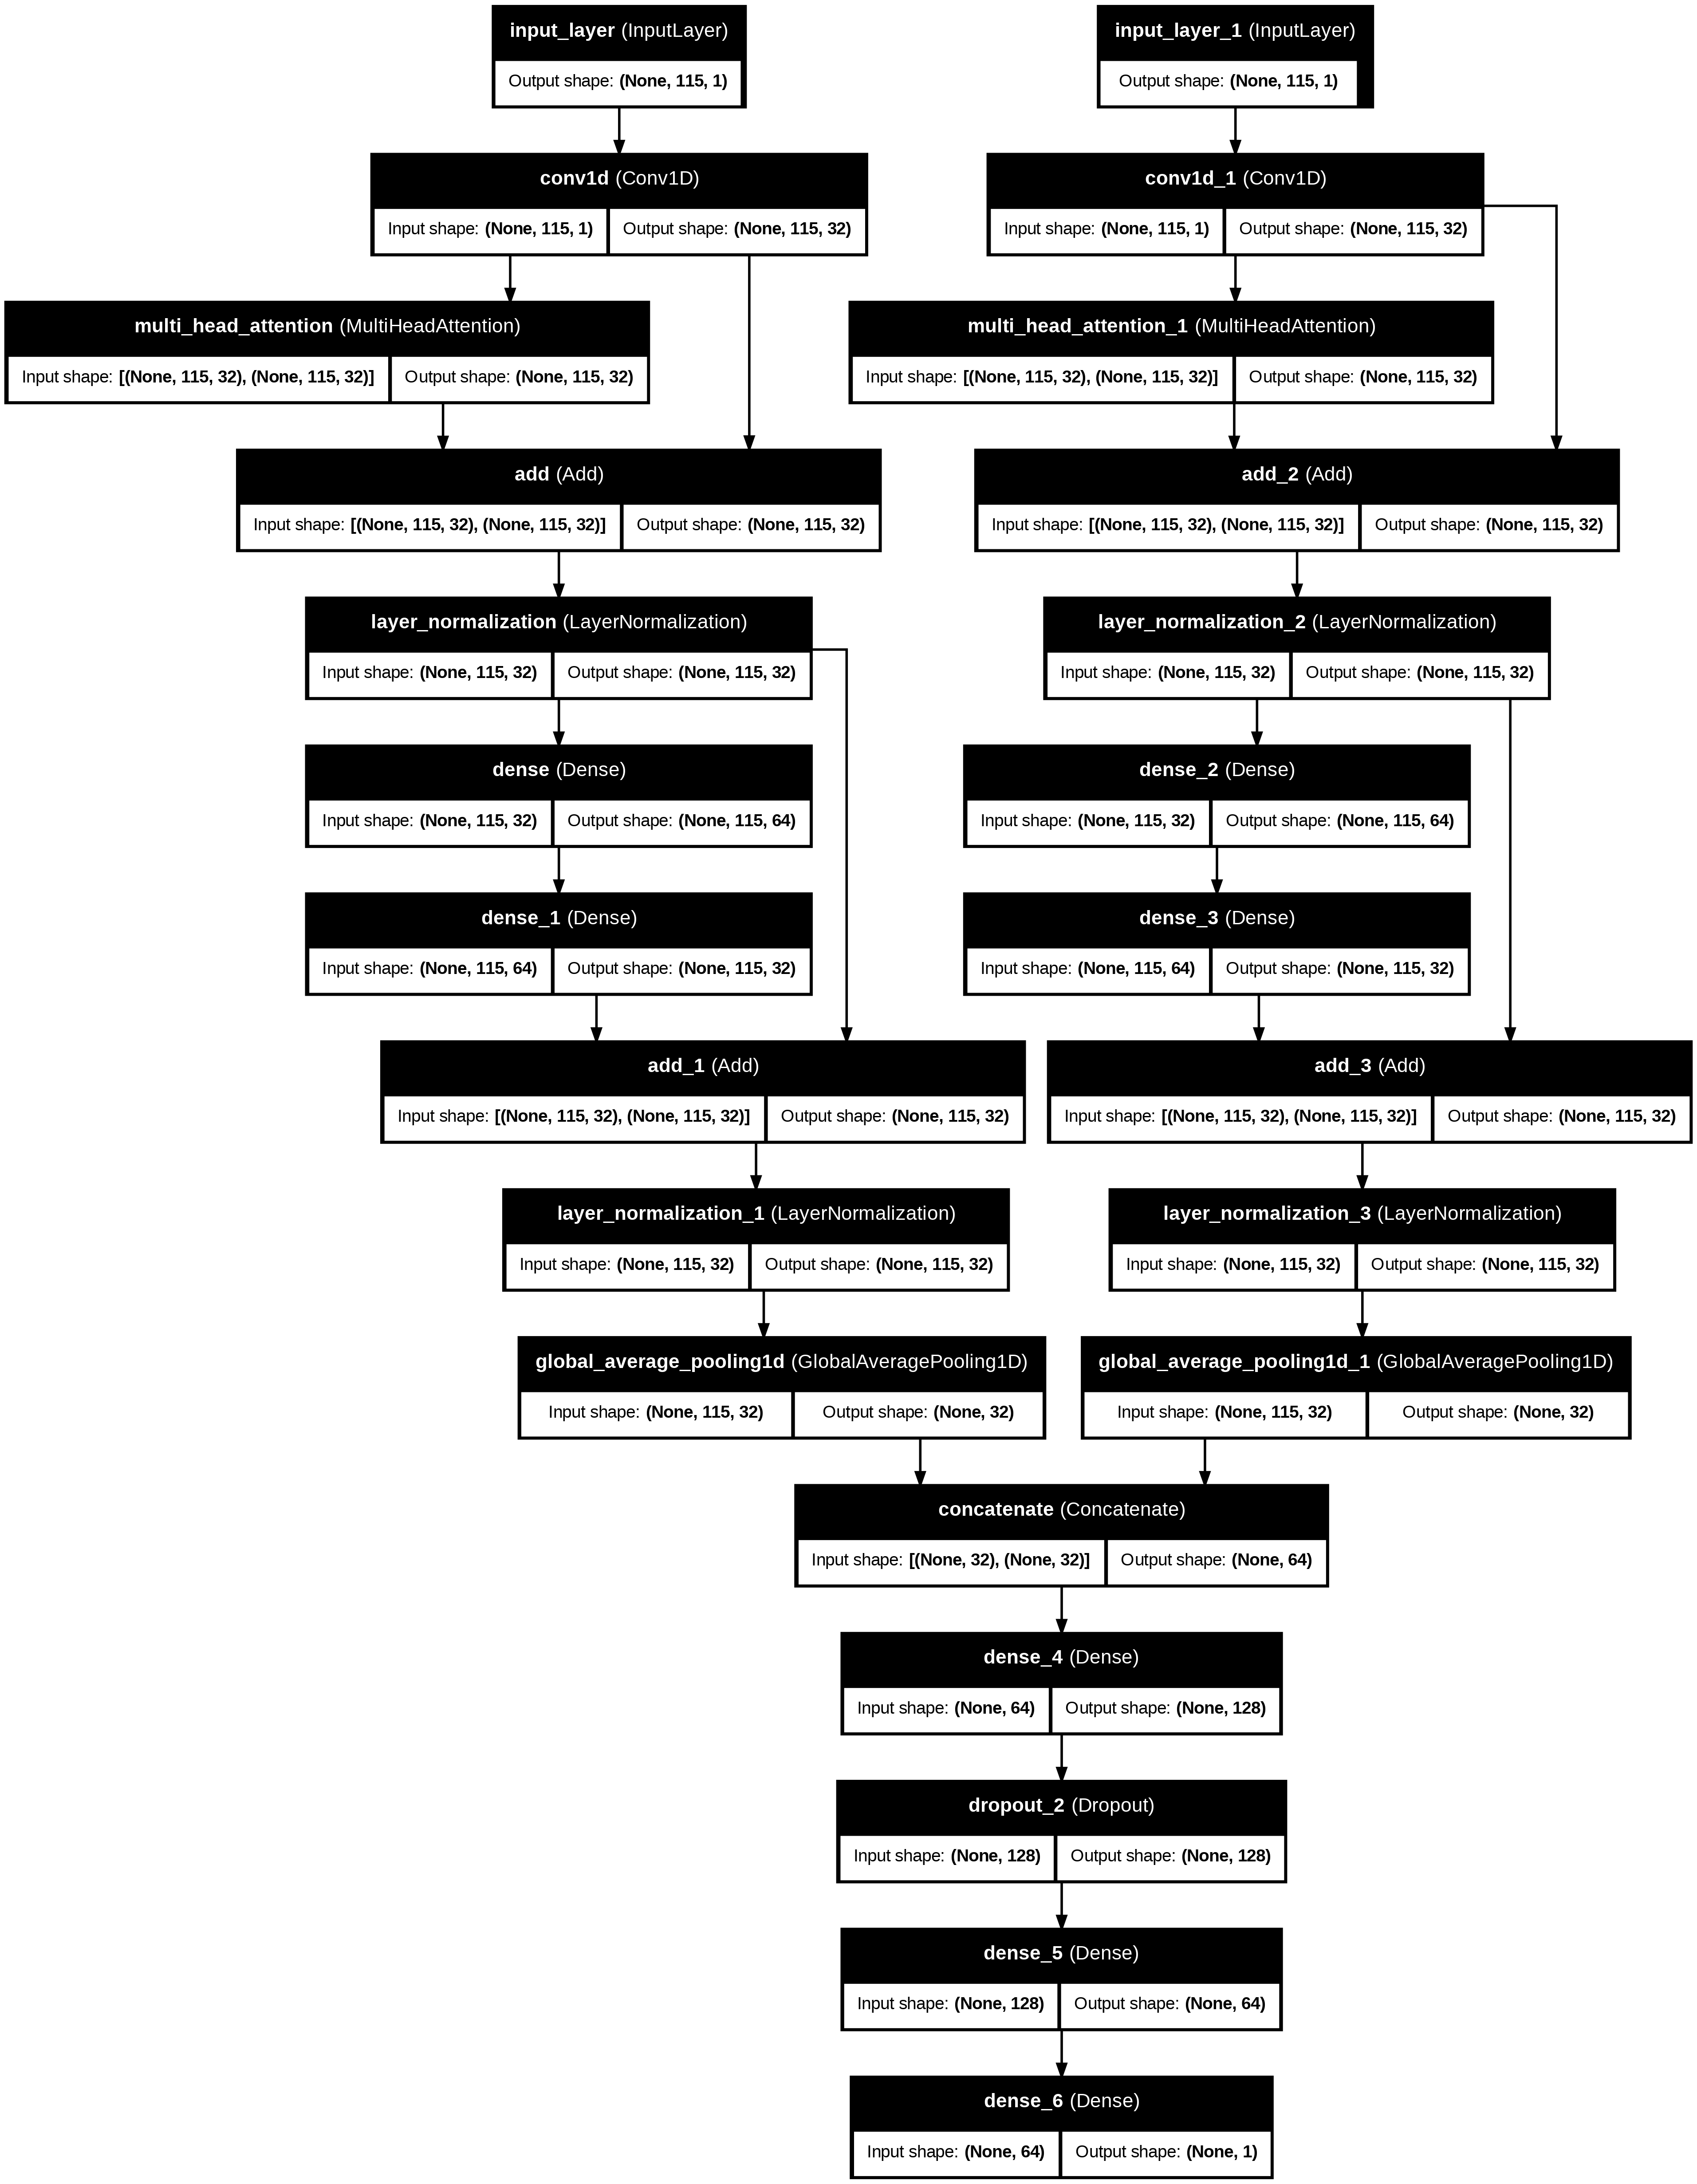

In [36]:
from tensorflow.keras.utils import plot_model
# Plot and save
plot_model(model2, to_file="model_architecture.png", show_shapes=True, show_layer_names=True)

In [37]:
def generate_mixed_data(X_landmark, X_mfcc, y, full_range=(0.1,1), landmark_range=(0.2,0.3)):
    total = len(X_landmark)
    
    # Random ratios
    full_input_ratio = np.random.uniform(*full_range)
    landmark_only_ratio = np.random.uniform(*landmark_range)
    mfcc_only_ratio = 1.0 - full_input_ratio - landmark_only_ratio

    # Fix if mfcc_only goes negative
    if mfcc_only_ratio < 0:
        mfcc_only_ratio = 0
        total_ratio = full_input_ratio + landmark_only_ratio
        full_input_ratio /= total_ratio
        landmark_only_ratio /= total_ratio

    # Calculate sizes
    n_full = int(full_input_ratio * total)
    n_landmark_only = int(landmark_only_ratio * total)
    n_mfcc_only = total - n_full - n_landmark_only  # Ensure total samples match

    # Shuffle
    indices = np.random.permutation(total)
    X_landmark = X_landmark[indices]
    X_mfcc = X_mfcc[indices]
    y = y[indices]

    # subsets
    X_landmark_full = X_landmark[:n_full]
    X_mfcc_full = X_mfcc[:n_full]
    y_full = y[:n_full]

    X_landmark_lo = X_landmark[n_full:n_full+n_landmark_only]
    X_mfcc_lo = np.zeros_like(X_mfcc[n_full:n_full+n_landmark_only])
    y_lo = y[n_full:n_full+n_landmark_only]

    X_landmark_mo = np.zeros_like(X_landmark[n_full+n_landmark_only:])
    X_mfcc_mo = X_mfcc[n_full+n_landmark_only:]
    y_mo = y[n_full+n_landmark_only:]

    # Combine
    X_landmark_mixed = np.concatenate([X_landmark_full, X_landmark_lo, X_landmark_mo])
    X_mfcc_mixed = np.concatenate([X_mfcc_full, X_mfcc_lo, X_mfcc_mo])
    y_mixed = np.concatenate([y_full, y_lo, y_mo])

    # Return data and ratios
    return X_landmark_mixed, X_mfcc_mixed, y_mixed, full_input_ratio, landmark_only_ratio, mfcc_only_ratio


In [38]:
import datetime
from tensorflow.keras.callbacks import TensorBoard
import tensorflow as tf

#TensorBoard log directory
log_dir = "logs/fit/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
tensorboard_callback = TensorBoard(log_dir=log_dir, histogram_freq=1)

#writer 
writer = tf.summary.create_file_writer(log_dir)

# Compile 
model2.compile(optimizer='adam',
               loss='binary_crossentropy',
               metrics=['accuracy'])

num_epochs = 500

for epoch in range(num_epochs):
    print(f"\nEpoch {epoch + 1}")
    
    # Generate new mixed data and ratios
    X_lm_mixed, X_mfcc_mixed, y_mixed, full_r, landmark_r, mfcc_r = generate_mixed_data(
        X_train_landmark, X_train_mfcc, y_train
    )
    
    # Print input ratios
    print(f"Ratios - Full Input: {full_r:.2f}, Landmark Only: {landmark_r:.2f}, MFCC Only: {mfcc_r:.2f}")
    
    # Train for 1 epoch
    history = model2.fit(
        [X_lm_mixed, X_mfcc_mixed], y_mixed,
        batch_size=32, epochs=1, verbose=0
    )
    
    # Extract and print loss and accuracy
    epoch_loss = history.history['loss'][0]
    epoch_acc = history.history['accuracy'][0]
    
    print(f"Loss: {epoch_loss:.4f} | Accuracy: {epoch_acc:.4f}")
    
    # 4. Log metrics to TensorBoard
    with writer.as_default():
        tf.summary.scalar("Loss", epoch_loss, step=epoch)
        tf.summary.scalar("Accuracy", epoch_acc, step=epoch)



Epoch 1
Ratios - Full Input: 0.74, Landmark Only: 0.26, MFCC Only: 0.00


I0000 00:00:1750307105.678841      93 service.cc:148] XLA service 0x7a1f88003580 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1750307105.679318      93 service.cc:156]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1750307106.631209      93 cuda_dnn.cc:529] Loaded cuDNN version 90300
I0000 00:00:1750307110.214099      93 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


Loss: 0.7113 | Accuracy: 0.4989

Epoch 2
Ratios - Full Input: 0.79, Landmark Only: 0.21, MFCC Only: 0.00
Loss: 0.6936 | Accuracy: 0.5154

Epoch 3
Ratios - Full Input: 0.25, Landmark Only: 0.22, MFCC Only: 0.54
Loss: 0.7006 | Accuracy: 0.5183

Epoch 4
Ratios - Full Input: 0.74, Landmark Only: 0.26, MFCC Only: 0.00
Loss: 0.6947 | Accuracy: 0.5147

Epoch 5
Ratios - Full Input: 0.72, Landmark Only: 0.28, MFCC Only: 0.00
Loss: 0.7033 | Accuracy: 0.5075

Epoch 6
Ratios - Full Input: 0.80, Landmark Only: 0.20, MFCC Only: 0.00
Loss: 0.6982 | Accuracy: 0.4896

Epoch 7
Ratios - Full Input: 0.44, Landmark Only: 0.23, MFCC Only: 0.33
Loss: 0.6921 | Accuracy: 0.5248

Epoch 8
Ratios - Full Input: 0.76, Landmark Only: 0.24, MFCC Only: 0.00
Loss: 0.6970 | Accuracy: 0.5118

Epoch 9
Ratios - Full Input: 0.64, Landmark Only: 0.23, MFCC Only: 0.13
Loss: 0.6979 | Accuracy: 0.4996

Epoch 10
Ratios - Full Input: 0.62, Landmark Only: 0.22, MFCC Only: 0.16
Loss: 0.6973 | Accuracy: 0.4838

Epoch 11
Ratios - Ful

In [39]:
pip install visualkeras

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 997.4/997.4 kB 20.0 MB/s eta 0:00:0000:01
Note: you may need to restart the kernel to use updated packages.


/usr/local/lib/python3.11/dist-packages/visualkeras/layered.py:86: UserWarning: The legend_text_spacing_offset parameter is deprecated and will be removed in a future release.
  warnings.warn("The legend_text_spacing_offset parameter is deprecated and will be removed in a future release.")


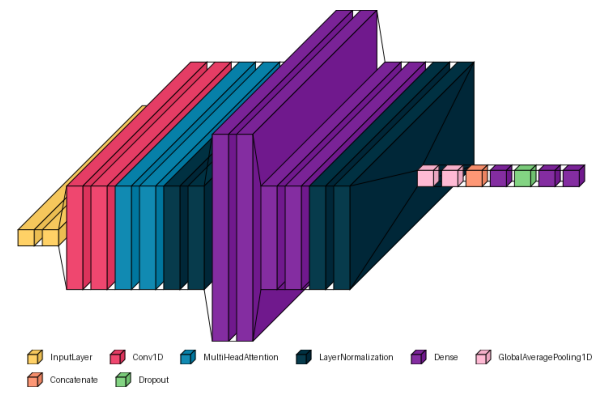

In [40]:
import visualkeras
import matplotlib.pyplot as plt
from PIL import Image

# Save model diagram to file
visualkeras.layered_view(model2, legend=True, draw_volume=True, to_file='model.png')

# Display it inline
img = Image.open('model.png')
plt.figure(figsize=(10, 5))
plt.imshow(img)
plt.axis('off')
plt.show()


In [41]:
loss, acc = model2.evaluate([X_test_landmark, X_test_mfcc], y_test)
print(f"Full Test Set Accuracy: {acc:.4f}")

19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - accuracy: 0.9298 - loss: 0.4774
Full Test Set Accuracy: 0.9380


19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 57ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


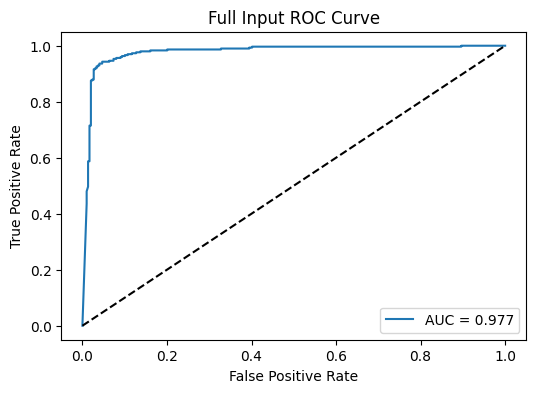

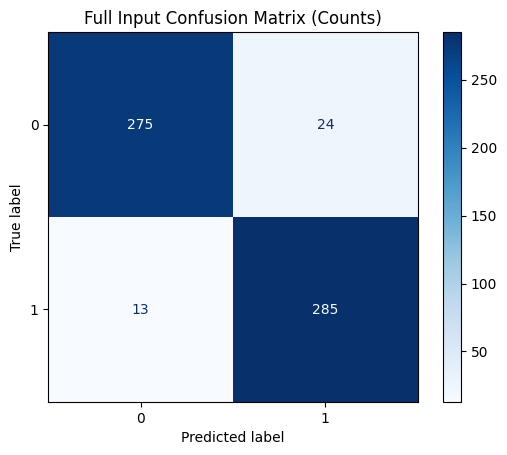

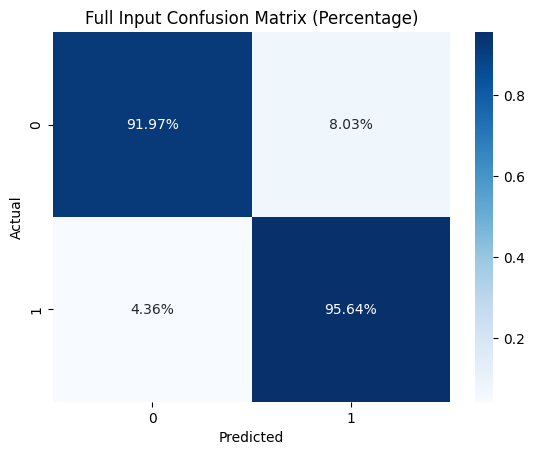

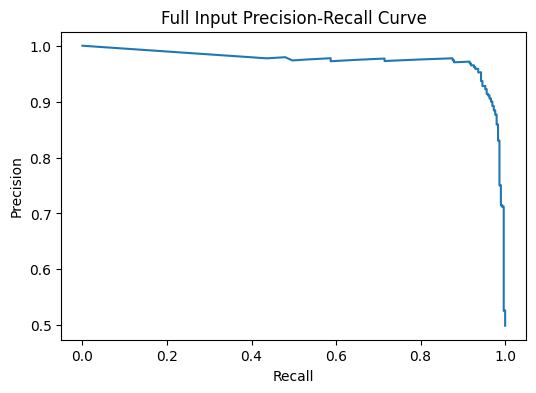

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


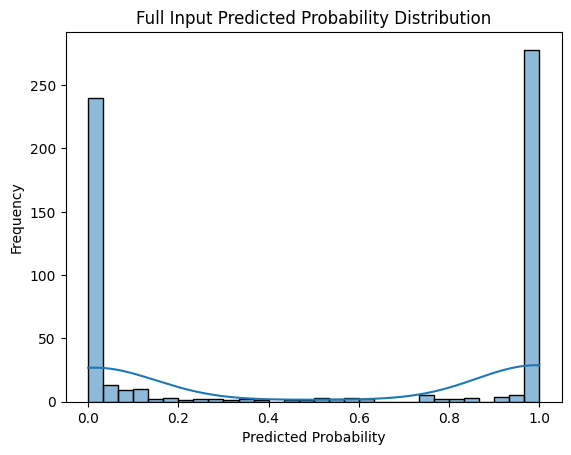

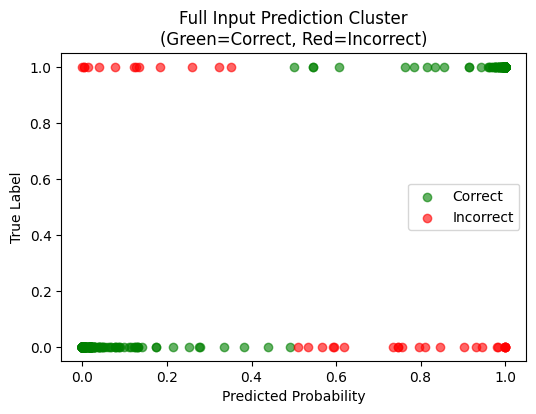


Full Input Overall Metrics:

Macro Average:
  Precision: 0.9386
  Recall:    0.9381
  F1-Score:  0.9380

Weighted Average:
  Precision: 0.9386
  Recall:    0.9380
  F1-Score:  0.9380


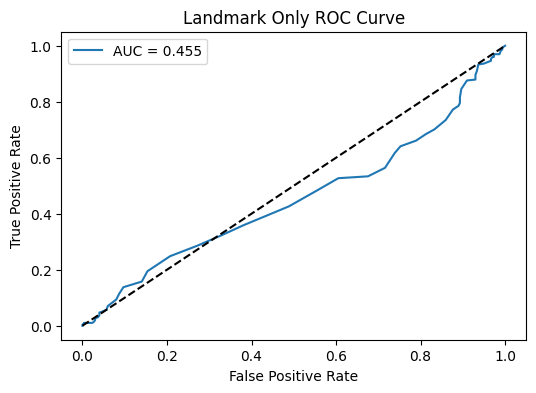

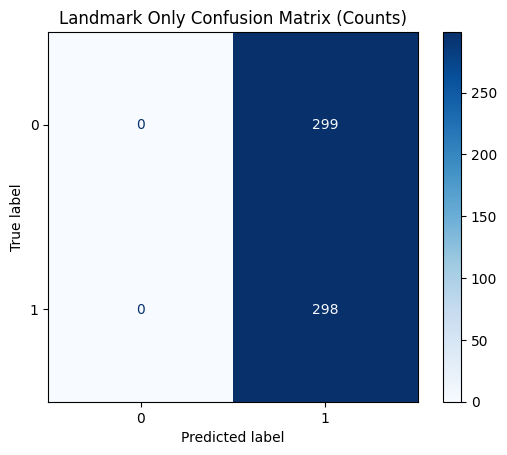

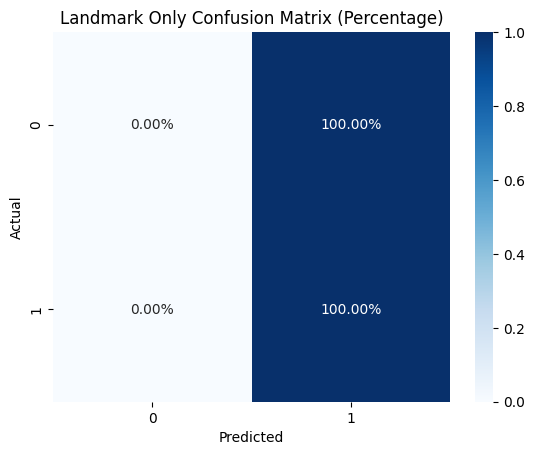

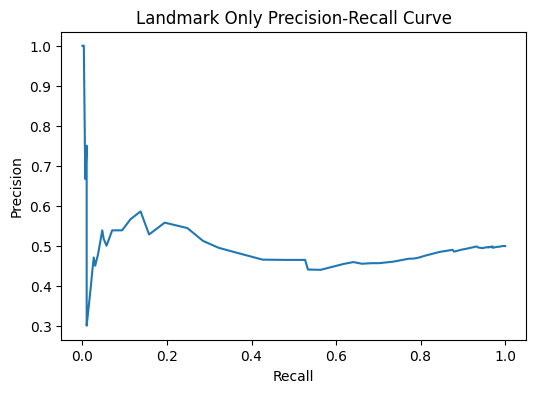

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


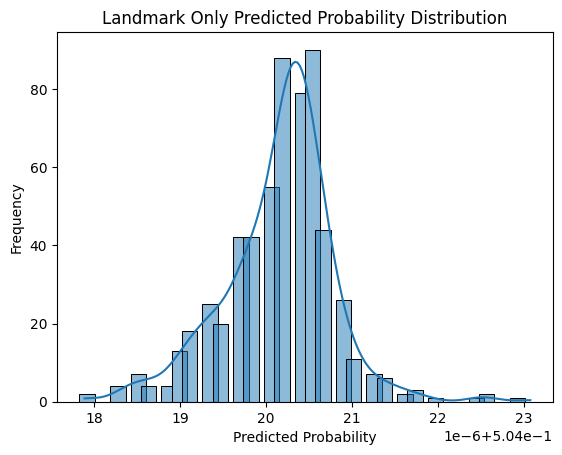

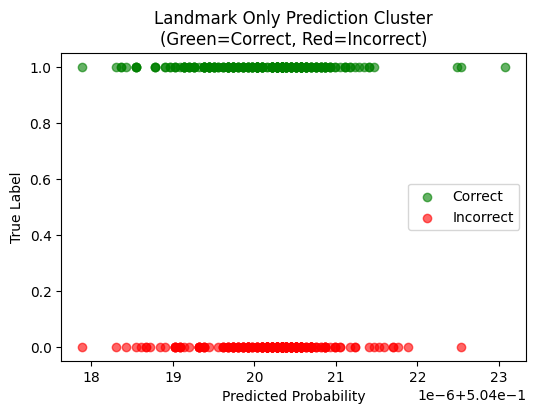


Landmark Only Overall Metrics:

Macro Average:
  Precision: 0.2496
  Recall:    0.5000
  F1-Score:  0.3330

Weighted Average:
  Precision: 0.2492
  Recall:    0.4992
  F1-Score:  0.3324


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


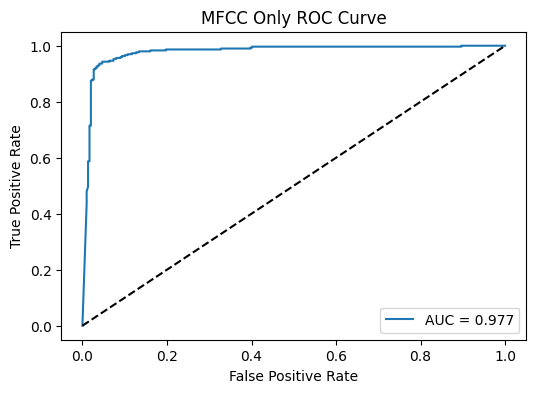

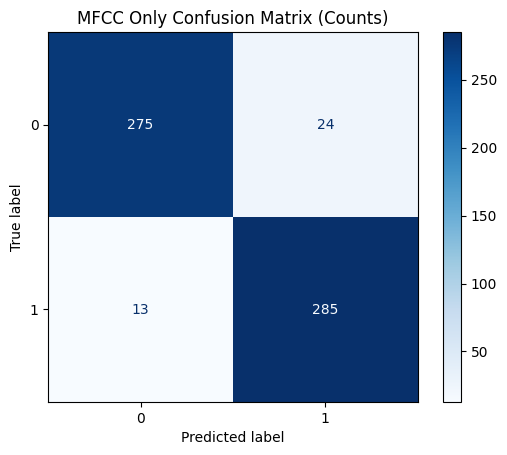

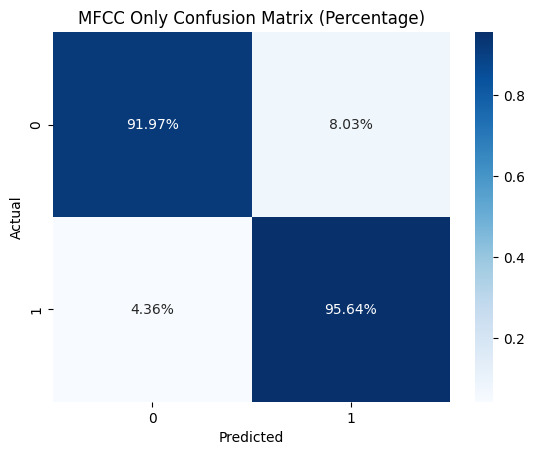

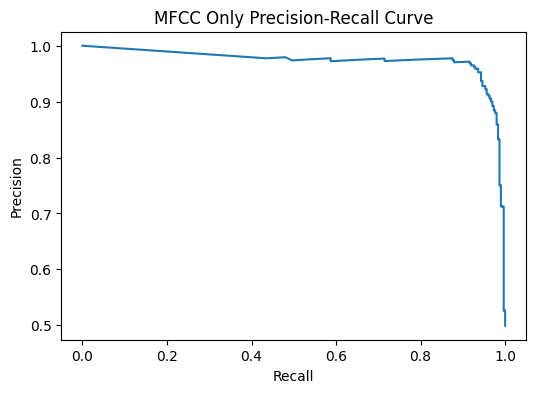

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


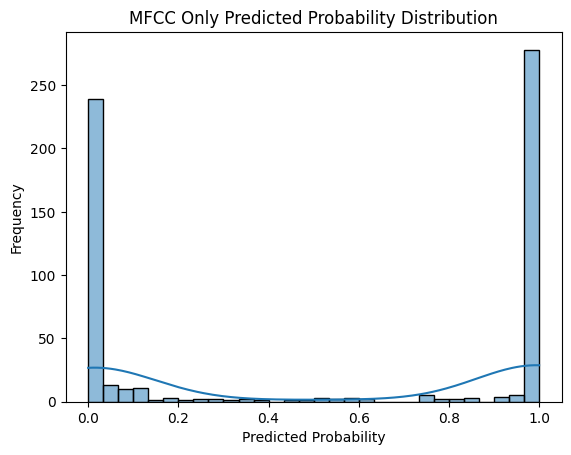

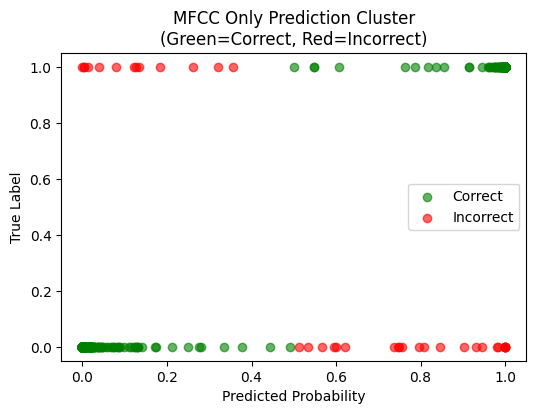


MFCC Only Overall Metrics:

Macro Average:
  Precision: 0.9386
  Recall:    0.9381
  F1-Score:  0.9380

Weighted Average:
  Precision: 0.9386
  Recall:    0.9380
  F1-Score:  0.9380

Full Test Set Accuracy: 0.9380
Facial Landmark Only Test Set Accuracy: 0.4992
MFCC Only Test Set Accuracy: 0.9380


In [42]:
# ✅ Import libraries
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    roc_curve, auc, confusion_matrix, ConfusionMatrixDisplay,
    precision_recall_curve, classification_report
)

# ✅ Predict for all three conditions
y_pred_full = model2.predict([X_test_landmark, X_test_mfcc]).flatten()

dummy_mfcc = np.zeros_like(X_test_mfcc)
y_pred_landmark = model2.predict([X_test_landmark, dummy_mfcc]).flatten()

dummy_landmark = np.zeros_like(X_test_landmark)
y_pred_mfcc = model2.predict([dummy_landmark, X_test_mfcc]).flatten()

# Convert to binary labels
y_true = y_test
y_label_full = (y_pred_full >= 0.5).astype(int)
y_label_landmark = (y_pred_landmark >= 0.5).astype(int)
y_label_mfcc = (y_pred_mfcc >= 0.5).astype(int)

# ✅ Helper function for all plots & metrics
def plot_all_metrics(y_true, y_prob, y_label, title):
    # --- ROC ---
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc = auc(fpr, tpr)
    plt.figure(figsize=(6, 4))
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
    plt.plot([0, 1], [0, 1], 'k--')
    plt.title(f"{title} ROC Curve")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend()
    plt.show()

    # --- Confusion Matrix (counts) ---
    cm = confusion_matrix(y_true, y_label)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap='Blues')
    plt.title(f"{title} Confusion Matrix (Counts)")
    plt.show()

    # --- Confusion Matrix (percentage) ---
    cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    sns.heatmap(cm_percent, annot=True, fmt=".2%", cmap='Blues')
    plt.title(f"{title} Confusion Matrix (Percentage)")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    # --- Precision-Recall Curve ---
    prec, rec, _ = precision_recall_curve(y_true, y_prob)
    plt.figure(figsize=(6, 4))
    plt.plot(rec, prec)
    plt.title(f"{title} Precision-Recall Curve")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.show()

    # --- Probability Distribution ---
    sns.histplot(y_prob, bins=30, kde=True)
    plt.title(f"{title} Predicted Probability Distribution")
    plt.xlabel("Predicted Probability")
    plt.ylabel("Frequency")
    plt.show()

    # --- Cluster Plot (Correct vs Incorrect) ---
    is_correct = y_true == y_label

    plt.figure(figsize=(6, 4))
    plt.scatter(y_prob[is_correct], y_true[is_correct],
                c='green', label='Correct', alpha=0.6)
    plt.scatter(y_prob[~is_correct], y_true[~is_correct],
                c='red', label='Incorrect', alpha=0.6)
    plt.title(f"{title} Prediction Cluster\n(Green=Correct, Red=Incorrect)")
    plt.xlabel("Predicted Probability")
    plt.ylabel("True Label")
    plt.legend()
    plt.show()

    # --- Overall Metrics (macro & weighted) ---
    print(f"\n{title} Overall Metrics:\n")
    report = classification_report(y_true, y_label, output_dict=True)
    print(f"Macro Average:")
    print(f"  Precision: {report['macro avg']['precision']:.4f}")
    print(f"  Recall:    {report['macro avg']['recall']:.4f}")
    print(f"  F1-Score:  {report['macro avg']['f1-score']:.4f}")
    print(f"\nWeighted Average:")
    print(f"  Precision: {report['weighted avg']['precision']:.4f}")
    print(f"  Recall:    {report['weighted avg']['recall']:.4f}")
    print(f"  F1-Score:  {report['weighted avg']['f1-score']:.4f}")

    # Optional: print full classification report if needed
    # print("\nFull classification report:")
    # print(classification_report(y_true, y_label, digits=4))


# ✅ Plot & print for each case
plot_all_metrics(y_true, y_pred_full, y_label_full, "Full Input")
plot_all_metrics(y_true, y_pred_landmark, y_label_landmark, "Landmark Only")
plot_all_metrics(y_true, y_pred_mfcc, y_label_mfcc, "MFCC Only")

# ✅ Also re-print model.evaluate for consistency
loss, acc = model2.evaluate([X_test_landmark, X_test_mfcc], y_test, verbose=0)
loss_landmark, acc_landmark = model2.evaluate([X_test_landmark, dummy_mfcc], y_test, verbose=0)
loss_mfcc, acc_mfcc = model2.evaluate([dummy_landmark, X_test_mfcc], y_test, verbose=0)

print(f"\nFull Test Set Accuracy: {acc:.4f}")
print(f"Facial Landmark Only Test Set Accuracy: {acc_landmark:.4f}")
print(f"MFCC Only Test Set Accuracy: {acc_mfcc:.4f}")


In [43]:
dummy_mfcc = np.zeros_like(X_test_mfcc)

loss_landmark, acc_landmark = model2.evaluate([X_test_landmark, dummy_mfcc], y_test)
print(f" Facial Landmark Only Test Set Accuracy: {acc_landmark:.4f}")


19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4972 - loss: 0.6932 
 Facial Landmark Only Test Set Accuracy: 0.4992


In [44]:
dummy_landmark = np.zeros_like(X_test_landmark)

loss_mfcc, acc_mfcc = model2.evaluate([dummy_landmark, X_test_mfcc], y_test)
print(f" MFCC Only Test Set Accuracy: {acc_mfcc:.4f}")

19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9298 - loss: 0.4774 
 MFCC Only Test Set Accuracy: 0.9380
